## Decision Tree

In [39]:
# import required libraries
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [40]:
df = pd.read_csv(r'C:\Users\subham\Desktop\TekWorks\Decisin-Tree\decision_tree_dataset.csv')
df.head()
df

,age,income,credit_score,city,gender,purchases,loan_amount,approved
0,41,16832.970365,646.435852,Hyderabad,Female,2,NaN,0
1,61,24958.920783,772.103370,Bangalore,Female,2,109037.369348,0
2,29,26661.565307,742.165011,Bangalore,Male,3,140981.063625,0
3,40,76918.367953,789.568381,Mumbai,Female,2,265765.286243,0
4,18,33446.160242,650.679984,Delhi,Male,4,187481.809910,0
...,...,...,...,...,...,...,...,...
1045,57,86596.286095,548.490581,Bangalore,Male,3,124867.554418,0
1046,67,55567.188101,NaN,Delhi,Female,4,19776.528421,1
1047,43,57155.612408,773.613072,Mumbai,Female,1,195876.623311,0
1048,60,35425.789422,549.604263,Mumbai,Male,4,115295.988140,0


In [41]:
df.isnull().sum()
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1050 entries, 0 to 1049
Data columns (total 8 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   age           1050 non-null   int64  
 1   income        947 non-null    float64
 2   credit_score  946 non-null    float64
 3   city          1050 non-null   object 
 4   gender        1050 non-null   object 
 5   purchases     1050 non-null   int64  
 6   loan_amount   947 non-null    float64
 7   approved      1050 non-null   int64  
dtypes: float64(3), int64(3), object(2)
memory usage: 65.8+ KB


In [42]:
df.describe()

,age,income,credit_score,purchases,loan_amount,approved
count,1050.000000,947.000000,946.000000,1050.000000,9.470000e+02,1050.000000
mean,43.737143,55807.648029,651.605495,2.934286,2.086066e+05,0.303810
std,15.021797,40021.647680,100.166162,1.603281,1.270517e+05,0.460121
min,18.000000,6556.169327,348.048784,0.000000,-5.768131e+04,0.000000
25%,31.000000,40886.541936,584.998140,2.000000,1.378232e+05,0.000000
50%,44.000000,50967.116222,650.052796,3.000000,1.971923e+05,0.000000
75%,56.000000,60643.014837,718.563117,4.000000,2.598691e+05,1.000000
max,69.000000,445126.233564,969.310757,9.000000,1.233105e+06,1.000000


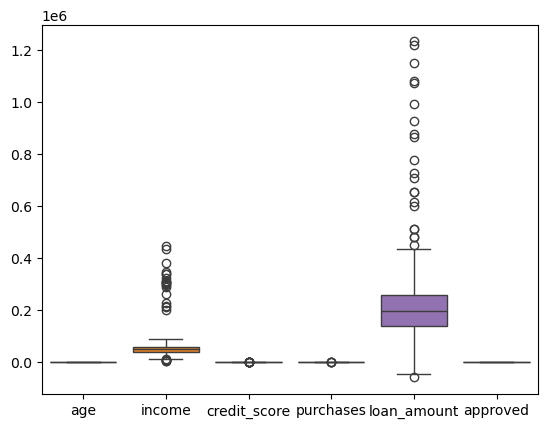

In [43]:
plot = sns.boxplot(data=df)

In [44]:
df['approved'].value_counts()

approved
0    731
1    319
Name: count, dtype: int64

<Axes: ylabel='income'>

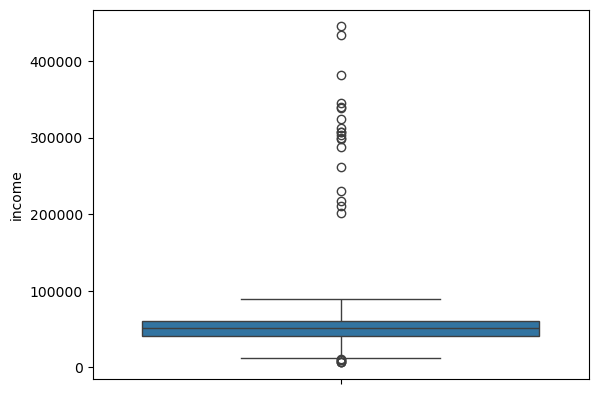

In [45]:
sns.boxplot(data=df['income'])

In [46]:
Q1 = df['income'].quantile(0.25)
Q3 = df['income'].quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR
outliers = df[(df['income'] >= lower_bound) & (df['income'] <= upper_bound)]


In [47]:
outliers

,age,income,credit_score,city,gender,purchases,loan_amount,approved
0,41,16832.970365,646.435852,Hyderabad,Female,2,NaN,0
1,61,24958.920783,772.103370,Bangalore,Female,2,109037.369348,0
2,29,26661.565307,742.165011,Bangalore,Male,3,140981.063625,0
3,40,76918.367953,789.568381,Mumbai,Female,2,265765.286243,0
4,18,33446.160242,650.679984,Delhi,Male,4,187481.809910,0
...,...,...,...,...,...,...,...,...
1045,57,86596.286095,548.490581,Bangalore,Male,3,124867.554418,0
1046,67,55567.188101,NaN,Delhi,Female,4,19776.528421,1
1047,43,57155.612408,773.613072,Mumbai,Female,1,195876.623311,0
1048,60,35425.789422,549.604263,Mumbai,Male,4,115295.988140,0


In [48]:
num_outliers = outliers.shape[0]
print(f"Number of outliers in the 'income' column: {num_outliers}")

Number of outliers in the 'income' column: 922


In [49]:
# Display the rows containing outliers
print("Rows containing outliers in the 'income' column:")
print(outliers)

Rows containing outliers in the 'income' column:
      age        income  credit_score       city  gender  purchases  \
0      41  16832.970365    646.435852  Hyderabad  Female          2   
1      61  24958.920783    772.103370  Bangalore  Female          2   
2      29  26661.565307    742.165011  Bangalore    Male          3   
3      40  76918.367953    789.568381     Mumbai  Female          2   
4      18  33446.160242    650.679984      Delhi    Male          4   
...   ...           ...           ...        ...     ...        ...   
1045   57  86596.286095    548.490581  Bangalore    Male          3   
1046   67  55567.188101           NaN      Delhi  Female          4   
1047   43  57155.612408    773.613072     Mumbai  Female          1   
1048   60  35425.789422    549.604263     Mumbai    Male          4   
1049   39  47923.160240    657.595527  Hyderabad    Male          4   

        loan_amount  approved  
0               NaN         0  
1     109037.369348         0  
2 

In [50]:
# Only loan amount outliers
Q1 = df['loan_amount'].quantile(0.25)
Q3 = df['loan_amount'].quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR
outliers_loan_amount = df[(df['loan_amount'] >= lower_bound) & (df['loan_amount'] <= upper_bound)]

In [51]:
outliers_loan_amount

,age,income,credit_score,city,gender,purchases,loan_amount,approved
1,61,24958.920783,772.103370,Bangalore,Female,2,109037.369348,0
2,29,26661.565307,742.165011,Bangalore,Male,3,140981.063625,0
3,40,76918.367953,789.568381,Mumbai,Female,2,265765.286243,0
4,18,33446.160242,650.679984,Delhi,Male,4,187481.809910,0
5,57,60504.648191,781.491445,Delhi,Female,3,223926.858722,1
...,...,...,...,...,...,...,...,...
1044,52,12925.332498,589.778794,Delhi,Male,3,262731.713308,0
1045,57,86596.286095,548.490581,Bangalore,Male,3,124867.554418,0
1046,67,55567.188101,NaN,Delhi,Female,4,19776.528421,1
1047,43,57155.612408,773.613072,Mumbai,Female,1,195876.623311,0


In [52]:
# Number of outliers in the 'loan_amount' column
num_outliers_loan_amount = outliers_loan_amount.shape[0]
print(f"Number of outliers in the 'loan_amount' column: {num_outliers_loan_amount}")

Number of outliers in the 'loan_amount' column: 925


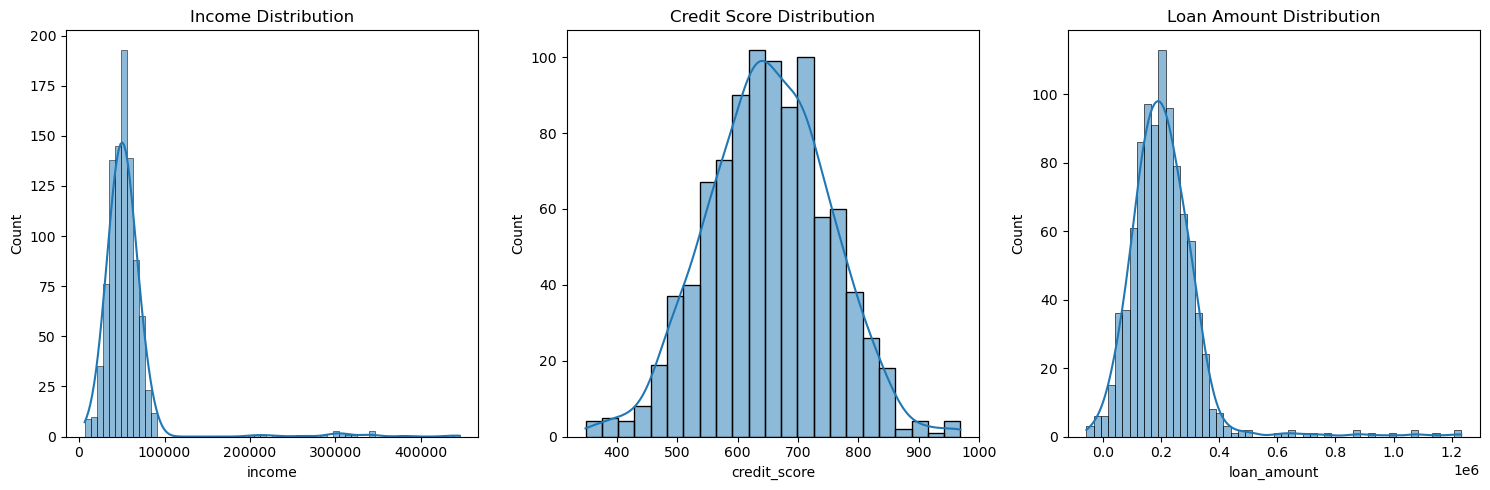

In [53]:
# Plot the histplot for income, credit_score, and loan_amount
plt.figure(figsize=(15, 5))
plt.subplot(1, 3, 1)
sns.histplot(df['income'], kde=True)
plt.title('Income Distribution')
plt.subplot(1, 3, 2)
sns.histplot(df['credit_score'], kde=True)
plt.title('Credit Score Distribution')
plt.subplot(1, 3, 3)
sns.histplot(df['loan_amount'], kde=True)
plt.title('Loan Amount Distribution')
plt.tight_layout()
plt.show()

In [54]:
# Fill the missing values in the 3 columns with the median value of each column
df['income'].fillna(df['income'].median(), inplace=True)
df['credit_score'].fillna(df['credit_score'].median(), inplace=True)
df['loan_amount'].fillna(df['loan_amount'].median(), inplace=True)
# Check for missing values again
print(df.isnull().sum())


age             0
income          0
credit_score    0
city            0
gender          0
purchases       0
loan_amount     0
approved        0
dtype: int64


C:\Windows\Temp\ipykernel_24092\2466446670.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['income'].fillna(df['income'].median(), inplace=True)
C:\Windows\Temp\ipykernel_24092\2466446670.py:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].me

In [55]:
def cap_outlier(column):
    Q1 = df[column].quantile(0.25)
    Q2 = df[column].quantile(0.75)
    IQR = Q2 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q2 + 1.5 * IQR
    df[column] = df[column].clip(lower_bound, upper_bound)

In [56]:
cap_outlier('income')
cap_outlier('loan_amount')
cap_outlier('credit_score')